## Multidimensional harmonic retrieval

<div style="text-align: justify; text-justify: inter-word;"> The goal of this demo is to illustrate the use of the basic canonical polyadic decomposition commands in an array processing application. We consider binary phase-shift keying (BPSK) signals impinging on a 10x10 uniform rectangular array (URA). The goal is to separate these signals and identify the directions of arrival. The harmonic structure due to the array geometry is not exploited in this demo; this can be done in the structured data fusion framework. This demo also illustrates the use of canonical polyadic decomposition in the case where values are missing due to sensor malfunctioning. 

Required packages for this demo

In [1]:
import numpy as np
import tensorlab as tl
import scipy.linalg as la
import matplotlib.pyplot as plt
%matplotlib inline
np.set_printoptions(precision=5, suppress=True)
rand = np.random.default_rng(1234).random

## Data
Three sources impinge on a URA with azimuth angles of $10^{\degree},$ $30^{\degree},$ and $70^{\degree},$  respectively, and with elevation angles of $20^{\degree},$ $30^{\degree},$ and $40^{\degree},$ respectively. We observe 15 time samples, such that a tensor $\mathbf{\mathcal{T}} \in \mathbb{C}^{10\times 10\times 15}$ is obtained with $t_{ijk}$ the observed signal from antenna  $(i,j)$ sampled at time instance $k$. Each source contributes a rank-1 term to the tensor. The vectors in the first and second mode are Vandermonde and the third mode contains the respective source signals multiplied by attenuation factors. Hence, the factor matrices in the first and second mode, denoted as $\mathbf{A}$ and $\mathbf{E},$ are Vandermonde matrices.

In [2]:
N = 15; R = 3; I = 10
azimuth_angles = np.array([10, 30, 70])  # azimuth angles in degrees
elevation_angles = np.array([20, 30, 40])  # elevation angles in degrees
lambda_ = 0.25  # wavelength of signal carriers
dx = 0.1  # sensor distance

A = np.zeros((I, R), dtype=complex)
E = np.zeros((I, R), dtype=complex)
zar = np.exp(2j * np.pi / lambda_ * np.sin(azimuth_angles * np.pi / 180) * dx)
zer = np.exp(2j * np.pi / lambda_ * np.sin(elevation_angles * np.pi / 180) * dx)
for i in range(I):
   A[i,:] = np.power(zar, i)
   E[i,:] = np.power(zer, i)    

The factor matrix in the third mode is the matrix containing the attenuated sources, denoted by $\mathbf{S}$:

In [3]:
S = np.round(rand((N, R))) * 2 - 1
attenuation_vector = np.array([1, 0.5, 0.25])
S = S * attenuation_vector.reshape(1, R)

The generated tensor is perturbed by Gaussian noise with a signal-to-noise ratio of 0 dB:

In [4]:
U = [A, E, S]
T = tl.PolyadicTensor(U)  
Tfull = np.asarray(T)  # Tf: full tensor
SNR = 0  # signal-to-noise ratio
Tnoisy = tl.noisy(Tfull, SNR)

We can visualize the 3rd-order noisy tensor slice-wise using the ``tl.slice3`` command.

In [12]:
# tl.slice3(Tnoisy)

The source signals are shown in the figure below:

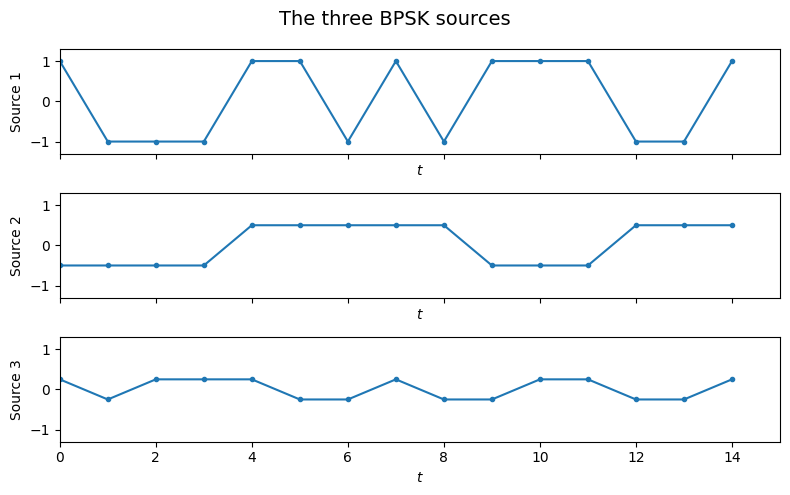

In [6]:
t = np.arange(0, N)
fig, axs = plt.subplots(
    nrows=R, ncols=1, sharex=True, sharey=True, figsize=(8, 5))
for i in range(R):
    axs[i].plot(t, S[:, i], ".-")
    axs[i].set_xlabel("$t$", fontsize=10)
    axs[i].set_ylabel(f"Source {i+1}", fontsize=10)
    axs[i].set_xlim([0, N])
    axs[i].set_ylim([-1.3, 1.3])
fig.suptitle("The three BPSK sources", fontsize=14)
fig.tight_layout()
plt.show()

We also plot the observed signals with and without noise, for antennas at (4, 5) and (5, 6) 

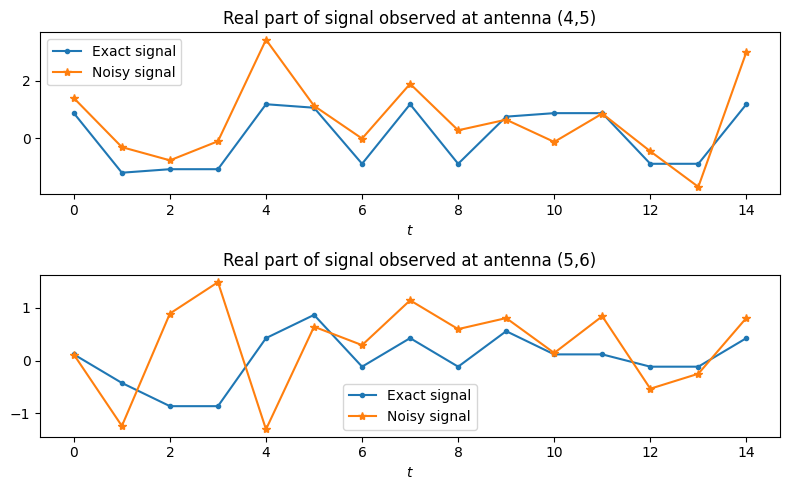

In [7]:
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(8, 5))

# Plotting for (4,5).
axs[0].plot(np.real(Tfull[4, 5, :]), ".-", label="Exact signal")
axs[0].plot(np.real(Tnoisy[4, 5, :]), "*-", label="Noisy signal")
axs[0].set_title("Real part of signal observed at antenna (4,5)")
axs[0].legend(loc="best")
axs[0].set_xlabel("$t$")

# Plotting for (5,6).
axs[1].plot(np.real(Tfull[5, 6, :]), ".-", label="Exact signal")
axs[1].plot(np.real(Tnoisy[5, 6, :]), "*-", label="Noisy signal")
axs[1].set_title("Real part of signal observed at antenna (5,6)")
axs[1].legend(loc="best")
axs[1].set_xlabel("$t$")
plt.tight_layout()
plt.show()

## Signal separation and direction-of-arrival estimation



The sources are separated by means of a CPD, without using the Vandermonde structure.

In [34]:
Tes = tl.cpd_gevd(T = Tnoisy, nterm = R)  # Tes: PolyacicTensor
Aest = Tes.factors[0]
Eest = Tes.factors[1]
Sest = Tes.factors[2]

The relative errors on the estimates of the factor matrices can be calculated as follow:

In [35]:
T.error(Tes)

[0.6369413939189481, 0.6929586261392583, 0.4277850470402338]

To fix the indeterminacies, we optimally permute and scale factor vectors of the estimated tensor as follows:

In [36]:
# Fix the permutation and scaling ambiguity.
indices = tl.match_congruence_kr(Tes.factors, T.factors) 
Tes_fix_perm = tl.PolyadicTensor([ui[:, indices] for ui in Tes.factors]) # permute the factor vectors.

scale = [           # scaling 
    np.diag(
        np.diag(np.conj(np.dot(np.conj(u.T), v)) / np.diag(np.dot(np.conj(v.T), v)))
    )
    for u, v in zip(T.factors, Tes_fix_perm.factors)
]

Tes_fix = tl.PolyadicTensor(
    [ui[:, indices] @ scale[k] for k, ui in enumerate(Tes_fix_perm.factors)])

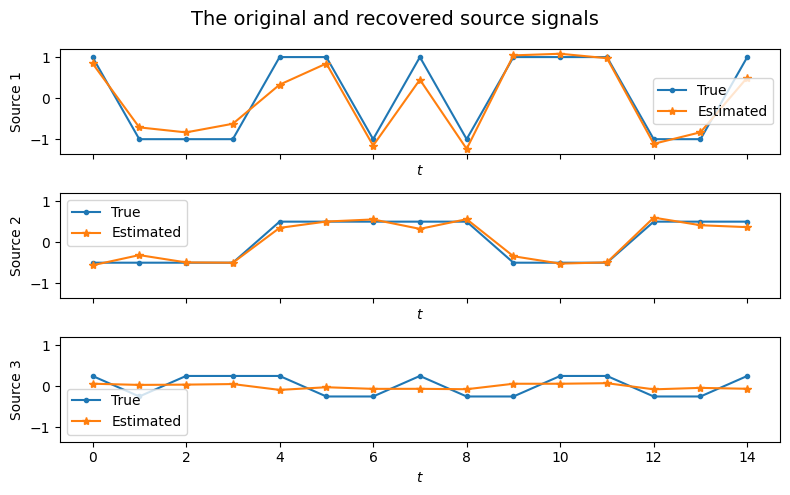

In [37]:
fig, axs = plt.subplots(nrows=R, ncols=1, sharex=True, sharey=True, figsize=(8, 5))
for i in range(R):
    axs[i].plot(t, np.real(T.factors[2][:, i]), ".-", label="True")
    axs[i].plot(t, np.real(Tes_fix.factors[2][:, i]), "*-", label="Estimated")
    axs[i].set_xlabel("$t$", fontsize=10)
    axs[i].set_ylabel(f"Source {i+1}", fontsize=10)
    axs[i].legend()
fig.suptitle("The original and recovered source signals", fontsize=14)
fig.tight_layout()
plt.show()

The direction-of-arrival angles can be determined using the shift invariance property of the individual Vandermonde vectors.

In [38]:
R = 3

azimuth_angles_est = np.zeros(azimuth_angles.shape)
elevation_angles_est = np.zeros(elevation_angles.shape)

for i in range(R):
    azimuth_z_est = np.linalg.lstsq(
        Tes_fix.factors[0][:-1, i].reshape(-1, 1),
        Tes_fix.factors[0][1:, i].reshape(-1, 1), rcond=None)[0]
    azimuth_angles_est[i] = np.arcsin(
        np.angle(azimuth_z_est) * lambda_ / (2 * np.pi * dx)) * (180 / np.pi)

    elevation_z_est = np.linalg.lstsq(
        Tes_fix.factors[1][:-1, i].reshape(-1, 1),
        Tes_fix.factors[1][1:, i].reshape(-1, 1), rcond=None)[0]
    elevation_angles_est[i] = np.arcsin(
        np.angle(elevation_z_est) * lambda_ / (2 * np.pi * dx)) * (180 / np.pi)

azimuth_err = np.abs(np.sort(azimuth_angles) - np.sort(azimuth_angles_est)) / np.abs(np.sort(azimuth_angles))
elevation_err = np.abs(np.sort(elevation_angles) - np.sort(elevation_angles_est)) / np.abs(np.sort(elevation_angles))

print("Error on azimuth angles = ", azimuth_err[0], "," , azimuth_err[1], "and", azimuth_err[2])
print("Error on elevation angles = ",  elevation_err[0], "," ,elevation_err[1],"and",elevation_err[2])

Error on azimuth angles =  0.039147424147352436 , 0.3664007063093057 and 0.5247569750520655
Error on elevation angles =  0.010549093608738503 , 0.07760549308907395 and 0.003674972701291601


Note that one can additionally impose the Vandermonde structure in the structured data fusion framework.

## Missing values due to broken sensors

If one or more antennas are broken, the tensor $ \mathcal{T} $ is incomplete. Tensorlab is able to process full, sparse and incomplete tensors. The missing entries can be indicated by NaN values. We consider the equivalent of a  deactivated sensor, a sensor that breaks half way the experiment, and a sensor that starts to work half way the experiment:

In [ ]:
# Mask some entries of the noisy tensor.
Tnoisy[1, 2, :] = np.nan
Tnoisy[4, 0, :Tnoisy.shape[2] // 2] = np.nan
Tnoisy[8, 6, Tnoisy.shape[2] // 2:] = np.nan
Tnoisy_in = tl.IncompleteTensor.from_dense(Tnoisy)

In [25]:
# Tes_in = tl.cpd_gevd(Tnoisy_in, 2)  # Tes: PolyacicTensor
# Aest_in = Tes.factors[0]
# Eest_in = Tes.factors[1]
# Sest_in = Tes.factors[2]

In [ ]:
# T.error(Tes)